In [1]:
import pandas as pd
import numpy as np
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch.nn as nn
import torch
from typing import Union
import warnings
from datetime import datetime
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from neuralforecast.core import NeuralForecast
from neuralforecast.models import PatchTST, TFT, TCN, TimeLLM, TiDE, iTransformer
from neuralforecast.losses.pytorch import MAE, MSE
import argparse
import sys
import os
from Data.Data_Generator_ILI_HHS_TimeSplit import prepare_ILI_data
from Utils import drop_last_n_samples, splitter
import contextlib
import io
import pytorch_lightning as pl
import logging
import warnings
import os
os.environ["NIXTLA_ID_AS_COL"] = "True"


In [2]:
path_to_data = "Data/ILINet.csv"
test_size = 0.2
train_df, test_df, df, data, number_of_time_series, length_time_series, forecasting_horizon, number_of_samples_in_test = prepare_ILI_data(path_to_data, test_size)


/sfs/weka/scratch/jrp5td/Geoff_test_2/Data/Data_Generator_ILI_HHS_TimeSplit.py:22: FutureWarning: The default value of numeric_only in DataFrame.mean is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  data = data.fillna(data.mean())
/sfs/weka/scratch/jrp5td/Geoff_test_2/Data/Data_Generator_ILI_HHS_TimeSplit.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:, 'y'] = df['y'].astype(float)


  0%|          | 0/1 [00:00<?, ?it/s][rank: 0] Seed set to 1
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=200` reached.


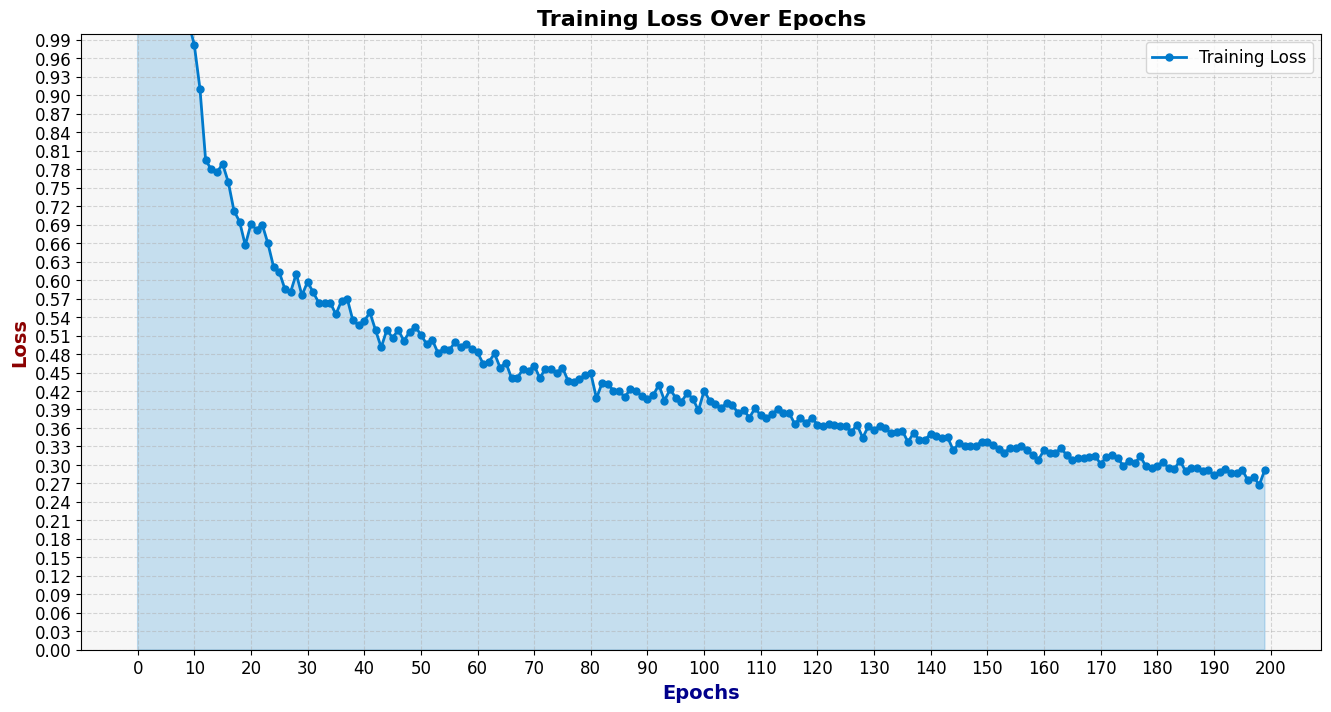

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=200` reached.


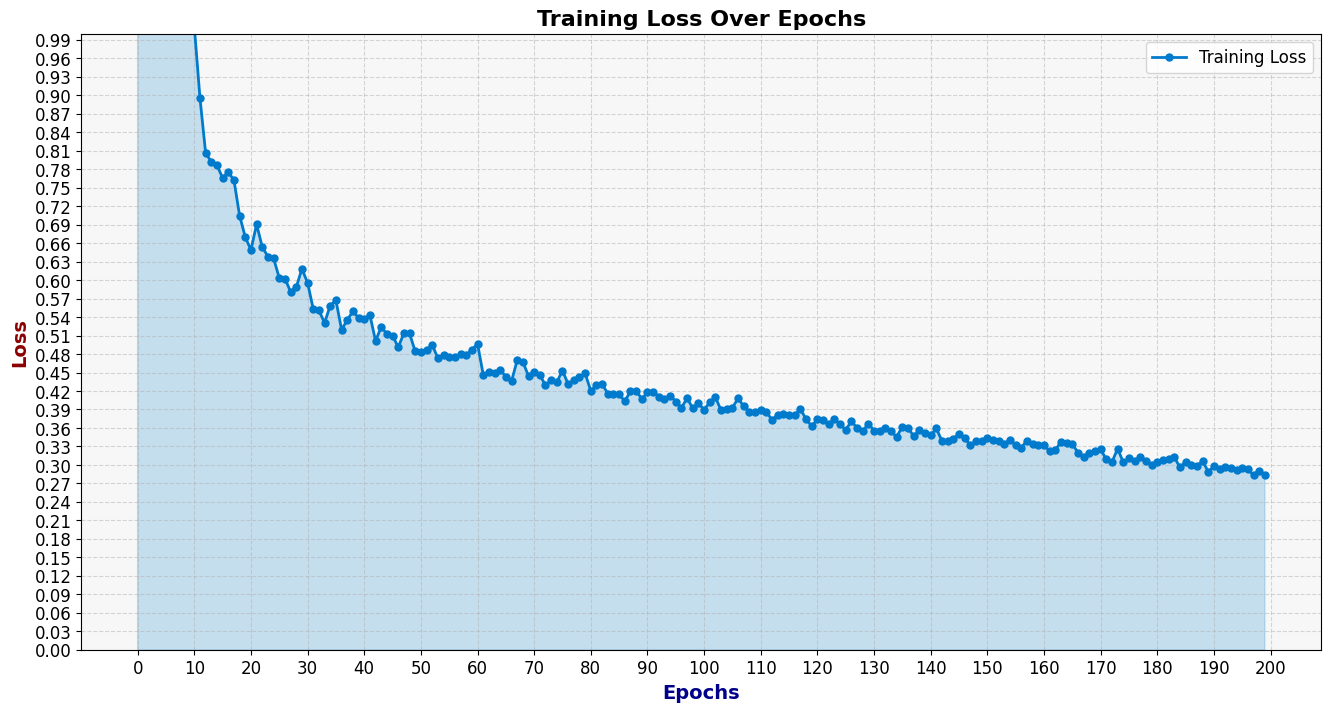

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=200` reached.


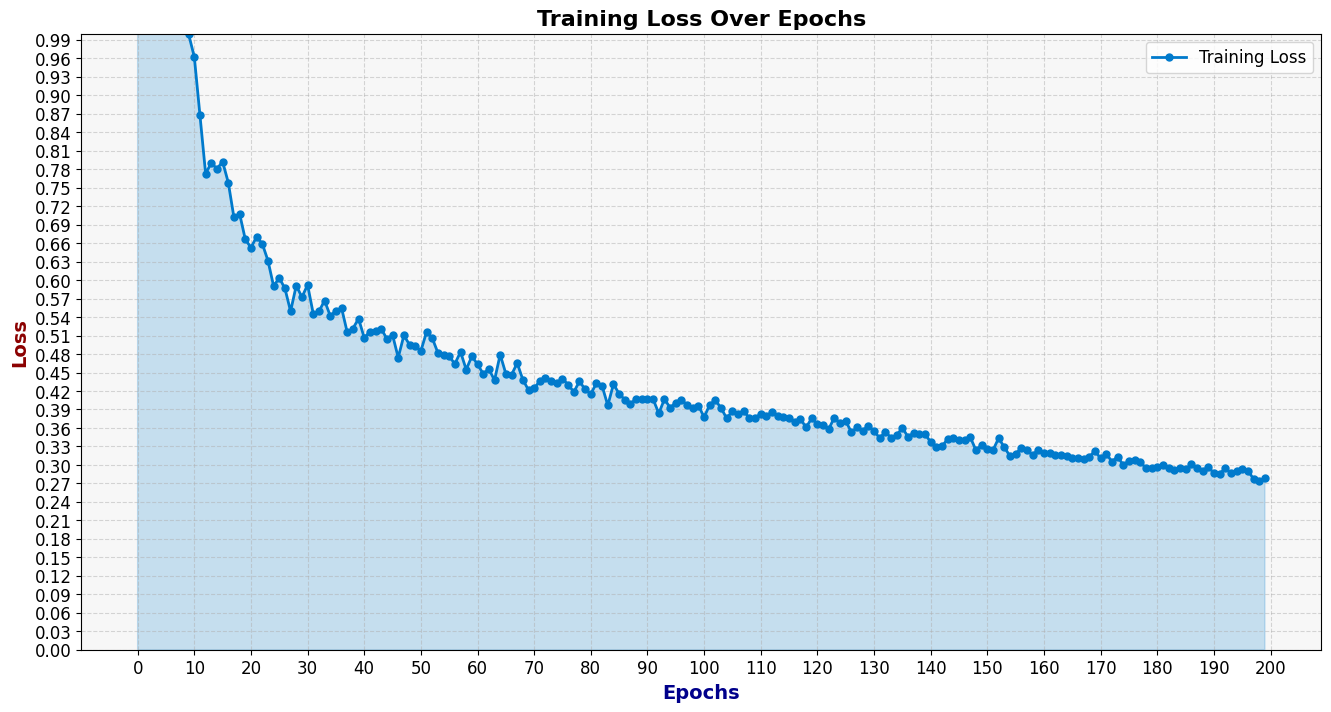

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=200` reached.


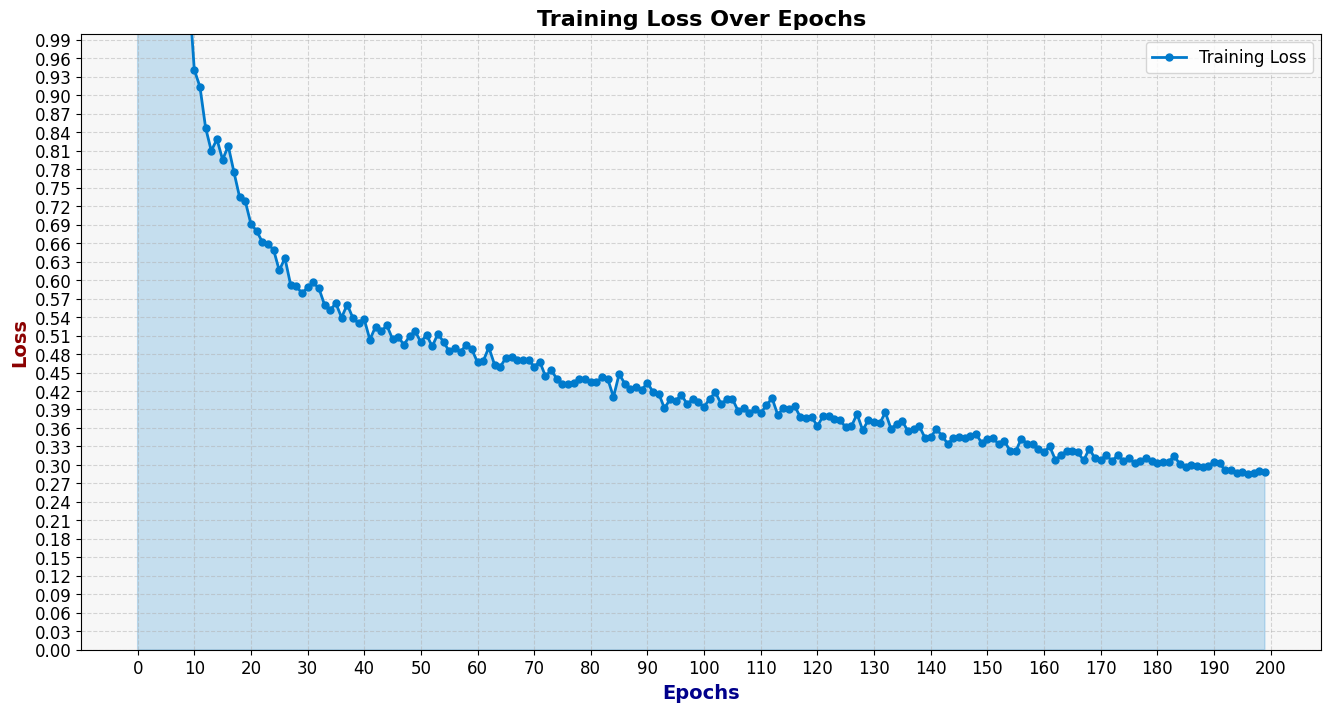

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=200` reached.


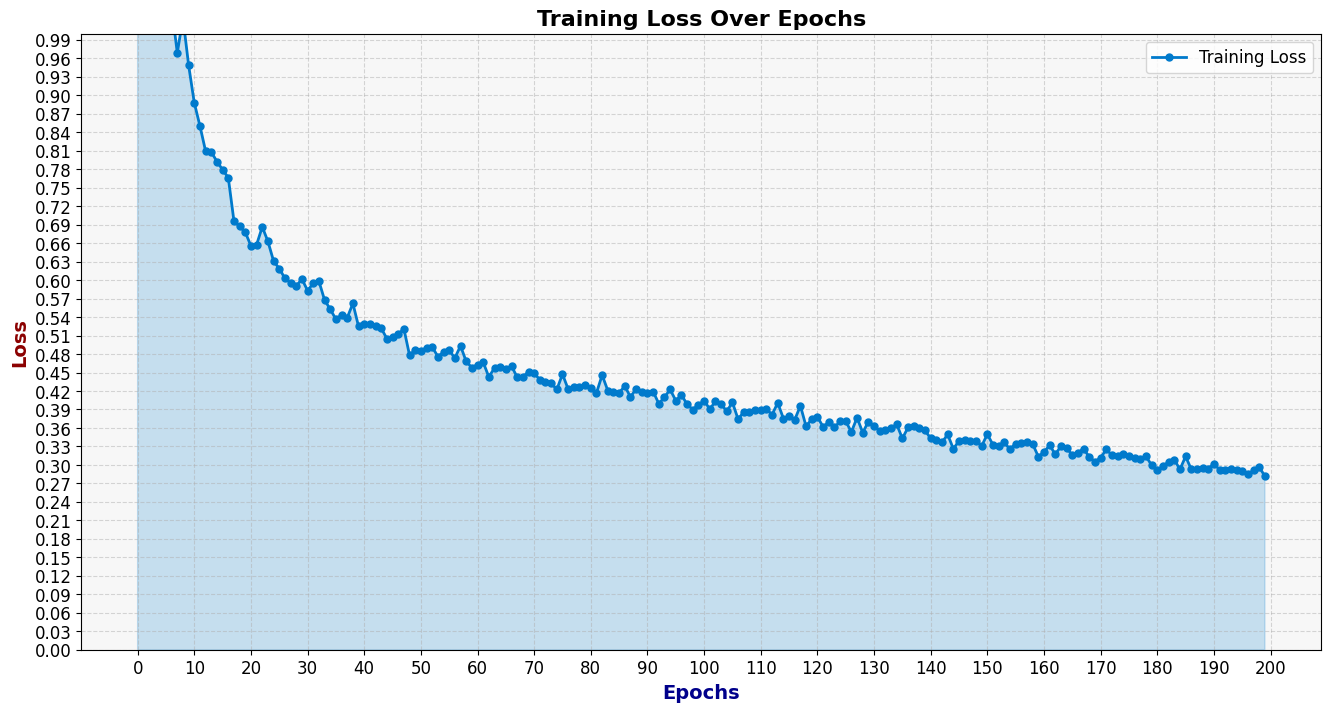

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=200` reached.


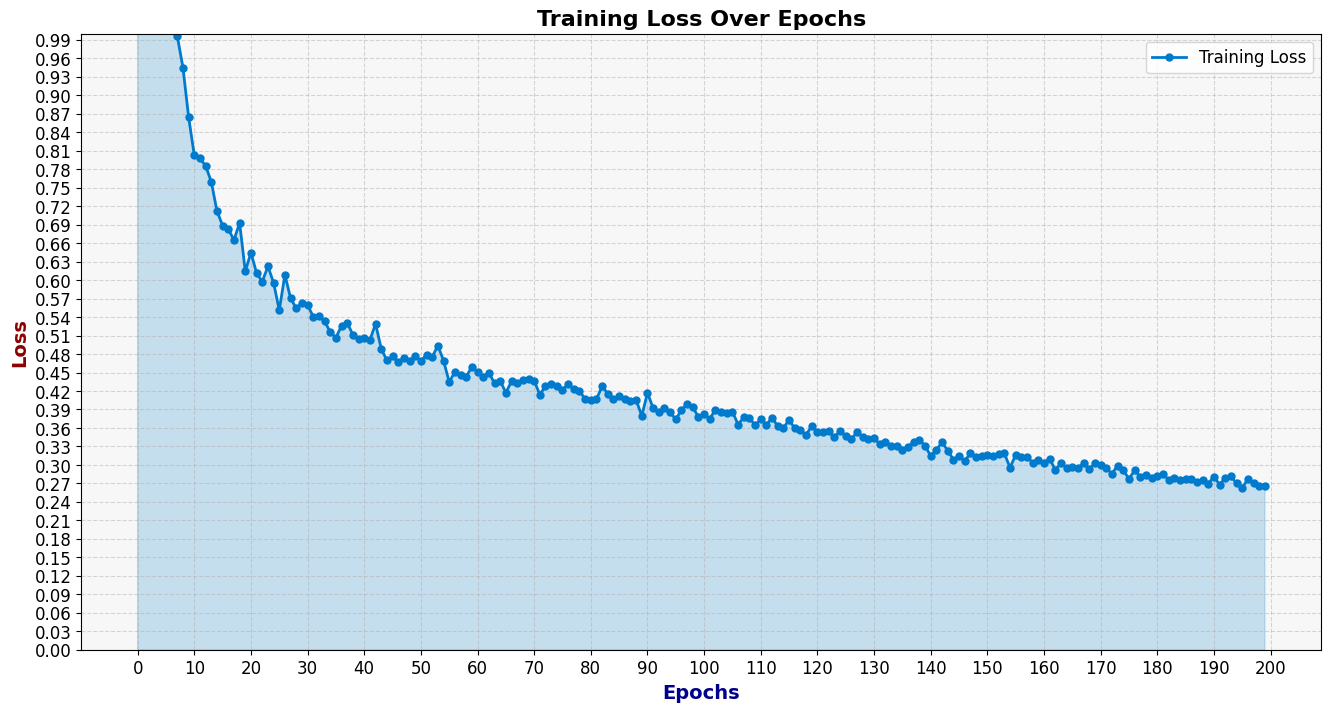

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Starting evaluation ....



  0%|          | 0/200 [00:00<?, ?it/s]GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


...

Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]


100%|██████████| 1/1 [02:18<00:00, 138.52s/it]


Evaluation ended.
    Dataset: ILI
    Model: iTransformer
    Target_series: % WEIGHTED ILI
    Feature: % WEIGHTED ILI
    Normalization: None

    Splitting_strategy: Time-based
    Validation: No
    Samples in one time series: 1000
    Samples in test part: 200
    Number of time series: 10
    Frequency: '1W'

    forecasting_horizon: 4
    Look back size: 52
    Step size: 1
    max_steps: 200
    loss: "MSE"
    learning_rate: 0.0001
    batch_size: 10
    scaler_type: None
    seed_neuralforecast: 6

    training loss (MSE): 0.26623
    ***RESULTS h1***
    MSE:    0.14764
    MAE:    0.23805
    SMAPE:  10.22923
    NNSE:   0.94171
    R²:     0.93810

    ***RESULTS h2***
    MSE:    0.35960
    MAE:    0.36529
    SMAPE:  15.53334
    NNSE:   0.86897
    R²:     0.84922

    ***RESULTS h3***
    MSE:    0.56838
    MAE:    0.46446
    SMAPE:  20.05293
    NNSE:   0.80755
    R²:     0.76168

    ***RESULTS h4***
    MSE:    0.76849
    MAE:    0.54435
    SMAPE:  23.62585
 

In [ ]:

for seed in [1,2,3,4,5,6]:
    
    model = "TiDE"
    forecasting_horizon = 4
    look_back_size=52
    batch_size = number_of_time_series
    learning_rate=1e-4
    max_steps = 200
    path_to_model = f"{model}/{model}_TimeSplit.py"
    scaler_type = None
    step_size=1 
    window_retrain = 200
    
    path_to_results = f"{model}/TB_h4_lr_{learning_rate}_epoch_{max_steps}_lbs_{look_back_size}_window_retrain_{window_retrain}"
    if not os.path.exists(path_to_results):
        os.makedirs(path_to_results)
        
    all_preds = pd.DataFrame()
    for s, index_splitter_train_test_data in enumerate(tqdm(range(number_of_samples_in_test, 0, -window_retrain))):
        
        train_df, _ = splitter(df, 'unique_id', index_splitter_train_test_data)
        number_of_samples_in_train = len(train_df)/number_of_time_series

        # Model configuration
        models = [TiDE(h=forecasting_horizon, 
                      input_size=look_back_size, 
                      n_series = 10,
                      max_steps=max_steps, 
                      learning_rate=learning_rate, 
                      loss=MSE(), random_seed=seed, 
                      scaler_type=scaler_type, 
                      batch_size=batch_size, 
                      step_size=step_size,
                      windows_batch_size=int(batch_size*(number_of_samples_in_train-forecasting_horizon-look_back_size+1))
                     )]
        nf = NeuralForecast(models=models, freq=1, local_scaler_type=scaler_type)
        nf.fit(train_df, verbose=True, val_size=0)

        # Extract training loss
        training_loss = getattr(nf.models[0], "train_trajectories", [])
        epochs = [epoch for epoch, loss in training_loss]
        loss_values = [loss for epoch, loss in training_loss]

        # Plot and save training loss
        plt.figure(figsize=(16, 8))
        plt.plot(epochs, loss_values, marker='o', linestyle='-', color='#007acc', linewidth=2, markersize=5, label='Training Loss')
        plt.xlabel("Epochs", fontsize=14, fontweight='bold', color='darkblue')
        plt.ylabel("Loss", fontsize=14, fontweight='bold', color='darkred')
        plt.title("Training Loss Over Epochs", fontsize=16, fontweight='bold', color='black')
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.gca().set_facecolor("#f7f7f7")
        plt.fill_between(epochs, loss_values, alpha=0.2, color='#007acc')
        plt.xticks(fontsize=12, color='black')
        plt.yticks(fontsize=12, color='black')
        ax = plt.gca()
        ax.set_ylim([0, 1])
        ax.yaxis.set_major_locator(ticker.MultipleLocator(0.03))
        ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
        plt.legend(fontsize=12, loc='upper right')
        plt.savefig(f"{path_to_results}/training_loss_plot_TB_h{forecasting_horizon}_s{seed}_{s}.png", dpi=300, bbox_inches='tight')
        plt.show()

        trainer = pl.Trainer(logger=False)
        logging.getLogger().setLevel(logging.ERROR)
        logging.getLogger("pytorch_lightning").setLevel(logging.CRITICAL)
        warnings.filterwarnings("ignore")

        def transform_df(df):
            first_ds_values = df.groupby("unique_id")["ds"].first().reset_index()
            first_ds_values.rename(columns={"ds": "first_ds"}, inplace=True)
            df_pivot = df.pivot(index='unique_id', columns='ds', values=model)
            df_pivot.columns = ['y_hat_1', 'y_hat_2', 'y_hat_3', 'y_hat_4']
            df_pivot = df_pivot.reset_index()
            df_pivot = df_pivot.merge(first_ds_values, on="unique_id")
            column_order = ["first_ds", "unique_id", 'y_hat_1', 'y_hat_2', 'y_hat_3', 'y_hat_4']
            df_pivot = df_pivot[column_order]
            return df_pivot

        print("Starting evaluation ....")
        for idx, i in enumerate(tqdm(range(index_splitter_train_test_data, index_splitter_train_test_data-window_retrain, -1))):
            _, data_batch_part = splitter(df, 'unique_id', i + look_back_size)
            data_batch_part = drop_last_n_samples(data_batch_part, 'unique_id', i)
            preds = nf.predict(data_batch_part)
            preds = preds.reset_index(drop=True)
            transformed_df = transform_df(preds)
            all_preds = pd.concat([all_preds, transformed_df], ignore_index=True)
        print("Evaluation ended.")

        def shift_up_by_group(df, group_col, columns_to_shift, shift_by, fill_value=0):
            shifted_groups = []
            unique_groups = df[group_col].unique()
            for grp_value in unique_groups:
                group_data = df[df[group_col] == grp_value].copy()
                group_data[columns_to_shift] = group_data[columns_to_shift].shift(shift_by)
                shifted_groups.append(group_data)
            df_shifted = pd.concat(shifted_groups, ignore_index=True)
            return df_shifted[columns_to_shift]


    all_preds = all_preds.sort_values(by=['unique_id', 'first_ds'], ascending=[True, True])
    test_df = test_df.sort_values(by=['unique_id', 'ds'], ascending=[True, True])
    results_df = all_preds.copy()
    results_df = results_df.reset_index(drop=True)
    test_df    = test_df.reset_index(drop=True)
    results_df['y_actual_1'] = test_df['y'].values
    results_df['y_actual_2'] = shift_up_by_group(test_df, group_col='unique_id', columns_to_shift=['y'],shift_by=-1, fill_value=0)
    results_df['y_actual_3'] = shift_up_by_group(test_df, group_col='unique_id', columns_to_shift=['y'],shift_by=-2, fill_value=0)
    results_df['y_actual_4'] = shift_up_by_group(test_df, group_col='unique_id', columns_to_shift=['y'],shift_by=-3, fill_value=0)


    def results_calculator(df, group_col, traget_y, predicted_y, shift_by, number_of_time_series, number_of_samples_in_test):
        filtered_df = df[['first_ds', 'unique_id', traget_y, predicted_y]]
        shifted_groups = []
        unique_groups = df[group_col].unique()
        for grp_value in unique_groups:
            group_data = df[df[group_col] == grp_value].copy()
            group_data.drop(group_data.tail(shift_by).index, inplace=True)
            shifted_groups.append(group_data)
        df_shifted = pd.concat(shifted_groups, ignore_index=True)

        Y_ACTUAL = df_shifted[traget_y].values.reshape(number_of_time_series, number_of_samples_in_test-shift_by)
        Y_HAT = df_shifted[predicted_y].values.reshape(number_of_time_series, number_of_samples_in_test-shift_by)

        mae = np.mean(np.abs(Y_ACTUAL - Y_HAT))
        mse = np.mean(np.square(Y_ACTUAL - Y_HAT))
        nnse = 1 / (2 - (1 - np.sum(np.square(Y_ACTUAL - Y_HAT)) / np.sum(np.square(Y_ACTUAL - np.mean(Y_ACTUAL)))))
        r2 = 1 - (np.sum(np.square(Y_ACTUAL - Y_HAT)) / np.sum(np.square(Y_ACTUAL - np.mean(Y_ACTUAL))))
        smape = 100 * np.mean(2 * np.abs(Y_HAT - Y_ACTUAL) / (np.abs(Y_ACTUAL) + np.abs(Y_HAT) + 1e-8))

        return mae, mse, nnse, smape, r2


    mae_1, mse_1, nnse_1, smape_1, r2_1 = results_calculator(results_df, 'unique_id', 'y_actual_1', 'y_hat_1', 0, number_of_time_series, number_of_samples_in_test)
    mae_2, mse_2, nnse_2, smape_2, r2_2 = results_calculator(results_df, 'unique_id', 'y_actual_2', 'y_hat_2', 1, number_of_time_series, number_of_samples_in_test)
    mae_3, mse_3, nnse_3, smape_3, r2_3 = results_calculator(results_df, 'unique_id', 'y_actual_3', 'y_hat_3', 2, number_of_time_series, number_of_samples_in_test)
    mae_4, mse_4, nnse_4, smape_4, r2_4 = results_calculator(results_df, 'unique_id', 'y_actual_4', 'y_hat_4', 3, number_of_time_series, number_of_samples_in_test)

    avg_mse = (mse_1+mse_2+mse_3+mse_4)/4

    # Save results
    config_text = f"""\
    Dataset: ILI
    Model: {model}
    Target_series: % WEIGHTED ILI
    Feature: % WEIGHTED ILI
    Normalization: None

    Splitting_strategy: Time-based
    Validation: No
    Samples in one time series: {length_time_series}
    Samples in test part: {number_of_samples_in_test}
    Number of time series: {number_of_time_series}
    Frequency: '1W'

    forecasting_horizon: {forecasting_horizon}
    Look back size: {look_back_size}
    Step size: {step_size}
    max_steps: {max_steps}
    loss: "MSE"
    learning_rate: {learning_rate}
    batch_size: {batch_size}
    scaler_type: {scaler_type}
    seed_neuralforecast: {seed}

    training loss (MSE): {loss_values[-1]:.5f}
    ***RESULTS h1***
    MSE:    {mse_1:.5f}
    MAE:    {mae_1:.5f}
    SMAPE:  {smape_1:.5f}
    NNSE:   {nnse_1:.5f}
    R²:     {r2_1:.5f}

    ***RESULTS h2***
    MSE:    {mse_2:.5f}
    MAE:    {mae_2:.5f}
    SMAPE:  {smape_2:.5f}
    NNSE:   {nnse_2:.5f}
    R²:     {r2_2:.5f}

    ***RESULTS h3***
    MSE:    {mse_3:.5f}
    MAE:    {mae_3:.5f}
    SMAPE:  {smape_3:.5f}
    NNSE:   {nnse_3:.5f}
    R²:     {r2_3:.5f}

    ***RESULTS h4***
    MSE:    {mse_4:.5f}
    MAE:    {mae_4:.5f}
    SMAPE:  {smape_4:.5f}
    NNSE:   {nnse_4:.5f}
    R²:     {r2_4:.5f}

    ***Average MSE***
    avg_mse: {avg_mse}
    """

    with open(f"{path_to_results}/Results_TB_h{forecasting_horizon}_s{seed}.txt", "w") as file:
        file.write(config_text)

    print(config_text)


In [ ]:
import os
import glob
import statistics
import re

def parse_metrics_from_file(filepath):
    """
    Parse the desired metrics from a single results file.
    Returns a dictionary with the following structure:
    {
      "training_loss": float,
      "avg_mse": float,
      "h1": {"MSE": float, "MAE": float, "SMAPE": float, "NNSE": float, "R2": float},
      "h2": {...},
      "h3": {...},
      "h4": {...}
    }
    If something is not found, returns None for that field.
    """

    # Initialize the dict with None (or any default) for each metric
    metrics_dict = {
        "training_loss": None,
        "avg_mse": None,
        "h1": {"MSE": None, "MAE": None, "SMAPE": None, "NNSE": None, "R2": None},
        "h2": {"MSE": None, "MAE": None, "SMAPE": None, "NNSE": None, "R2": None},
        "h3": {"MSE": None, "MAE": None, "SMAPE": None, "NNSE": None, "R2": None},
        "h4": {"MSE": None, "MAE": None, "SMAPE": None, "NNSE": None, "R2": None},
    }

    # Regex patterns to extract numbers (floats). 
    # We'll look for lines like: "training loss (MSE): 0.39443" or "MSE:    0.15226"
    # Adjust the patterns if your file format changes.
    pattern_training_loss = re.compile(r"training loss.*:\s*([0-9.]+)")
    pattern_avg_mse = re.compile(r"avg_mse:\s*([0-9.]+)")

    # For lines like "***RESULTS h1***" we capture h1
    # For lines like "MSE:\s*([0-9.]+)"
    pattern_horizon = re.compile(r"\*\*\*RESULTS\s+(h[0-9]+)\*\*\*")
    pattern_key_value = re.compile(r"(MSE|MAE|SMAPE|NNSE|R²?):\s*([0-9.]+)")

    current_horizon = None

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            # 1) Training Loss
            train_match = pattern_training_loss.search(line)
            if train_match:
                metrics_dict["training_loss"] = float(train_match.group(1))
                continue

            # 2) Average MSE
            avg_mse_match = pattern_avg_mse.search(line)
            if avg_mse_match:
                metrics_dict["avg_mse"] = float(avg_mse_match.group(1))
                continue

            # 3) Detect horizon header (e.g. ***RESULTS h1***)
            horizon_match = pattern_horizon.search(line)
            if horizon_match:
                current_horizon = horizon_match.group(1)  # e.g. 'h1', 'h2', etc.
                continue

            # 4) Inside horizon block, parse lines like "MSE:    0.15226"
            if current_horizon is not None:
                kv_match = pattern_key_value.search(line)
                if kv_match:
                    metric_name = kv_match.group(1)  # e.g. 'MSE'
                    metric_value = float(kv_match.group(2))

                    # Correct potential mismatch 'R²' vs 'R2' dictionary key
                    if metric_name.startswith('R'):
                        metric_name = "R2"

                    metrics_dict[current_horizon][metric_name] = metric_value

    return metrics_dict


def main(results_folder="path/to/results_folder"):
    """
    1. Collect all .txt files (or any extension) from the specified results_folder
    2. Parse metrics for each file
    3. Aggregate all metrics (mean, std)
    """

    # A structure to accumulate metric values across all files
    # We'll store lists, then compute mean and std afterwards
    all_metrics = {
        "training_loss": [],
        "avg_mse": [],
        "h1": {"MSE": [], "MAE": [], "SMAPE": [], "NNSE": [], "R2": []},
        "h2": {"MSE": [], "MAE": [], "SMAPE": [], "NNSE": [], "R2": []},
        "h3": {"MSE": [], "MAE": [], "SMAPE": [], "NNSE": [], "R2": []},
        "h4": {"MSE": [], "MAE": [], "SMAPE": [], "NNSE": [], "R2": []},
    }

    # Modify the glob pattern as needed (e.g. *.txt, *.log, etc.)
    file_list = glob.glob(os.path.join(results_folder, "*.txt"))

    for file_path in file_list:
        parsed = parse_metrics_from_file(file_path)

        # Append each metric if found
        if parsed["training_loss"] is not None:
            all_metrics["training_loss"].append(parsed["training_loss"])
        if parsed["avg_mse"] is not None:
            all_metrics["avg_mse"].append(parsed["avg_mse"])

        for horizon in ["h1", "h2", "h3", "h4"]:
            for mkey in ["MSE", "MAE", "SMAPE", "NNSE", "R2"]:
                val = parsed[horizon].get(mkey, None)
                if val is not None:
                    all_metrics[horizon][mkey].append(val)

    # Helper to compute mean and sample std
    def mean_std(values):
        if len(values) == 0:
            return (None, None)
        return (statistics.mean(values), statistics.stdev(values))

    # Print aggregated results
    print("===== AGGREGATED RESULTS ACROSS ALL FILES =====")
    # training_loss
    mean_val, std_val = mean_std(all_metrics["training_loss"])
    print(f"Training Loss (MSE): mean={mean_val:.3f}, std={std_val:.3f}")

    # avg_mse
    mean_val, std_val = mean_std(all_metrics["avg_mse"])
    print(f"Average MSE:         mean={mean_val:.3f}, std={std_val:.3f}")

    # For each horizon and each metric
    for horizon in ["h1", "h2", "h3", "h4"]:
        print(f"\n--- {horizon.upper()} ---")
        for metric_name in ["MSE", "MAE", "SMAPE", "NNSE", "R2"]:
            mean_val, std_val = mean_std(all_metrics[horizon][metric_name])
            print(f"{metric_name}: mean={mean_val:.3f}, std={std_val:.3f}")


     
    
path_to_results = f"{model}/TB_h4_lr_{learning_rate}_epoch_{max_steps}_lbs_{look_back_size}_window_retrain_{window_retrain}"
main(results_folder=path_to_results)





## TiDE
===== AGGREGATED RESULTS ACROSS ALL FILES =====

Average MSE:         mean=0.591, std=0.006

--- H1 ---
MSE: mean=0.183, std=0.009
MAE: mean=0.243, std=0.008
SMAPE: mean=9.568, std=0.374
NNSE: mean=0.929, std=0.003
R2: mean=0.923, std=0.004

--- H2 ---
MSE: mean=0.457, std=0.011
MAE: mean=0.386, std=0.005
SMAPE: mean=14.989, std=0.227
NNSE: mean=0.839, std=0.003
R2: mean=0.808, std=0.005

--- H3 ---
MSE: mean=0.742, std=0.011
MAE: mean=0.500, std=0.004
SMAPE: mean=19.500, std=0.164
NNSE: mean=0.763, std=0.003
R2: mean=0.689, std=0.005

--- H4 ---
MSE: mean=0.982, std=0.014
MAE: mean=0.587, std=0.005
SMAPE: mean=23.005, std=0.217
NNSE: mean=0.708, std=0.003
R2: mean=0.588, std=0.006


## TCN
===== AGGREGATED RESULTS ACROSS ALL FILES =====

Average MSE:         mean=0.587, std=0.070

--- H1 ---
MSE: mean=0.322, std=0.131
MAE: mean=0.379, std=0.111
SMAPE: mean=16.407, std=5.143
NNSE: mean=0.883, std=0.042
R2: mean=0.865, std=0.055

--- H2 ---
MSE: mean=0.494, std=0.076
MAE: mean=0.454, std=0.075
SMAPE: mean=19.180, std=3.604
NNSE: mean=0.829, std=0.022
R2: mean=0.793, std=0.032

--- H3 ---
MSE: mean=0.661, std=0.052
MAE: mean=0.526, std=0.028
SMAPE: mean=22.088, std=1.398
NNSE: mean=0.783, std=0.013
R2: mean=0.723, std=0.022

--- H4 ---
MSE: mean=0.869, std=0.065
MAE: mean=0.615, std=0.039
SMAPE: mean=25.691, std=1.829
NNSE: mean=0.733, std=0.015
R2: mean=0.636, std=0.027

## TimeLLM
===== AGGREGATED RESULTS ACROSS ALL FILES =====

Average MSE:         mean=0.724, std=0.054

--- H1 ---
MSE: mean=0.394, std=0.062
MAE: mean=0.408, std=0.033
SMAPE: mean=17.925, std=1.324
NNSE: mean=0.858, std=0.019
R2: mean=0.835, std=0.026

--- H2 ---
MSE: mean=0.617, std=0.058
MAE: mean=0.501, std=0.023
SMAPE: mean=21.300, std=0.940
NNSE: mean=0.795, std=0.015
R2: mean=0.741, std=0.025

--- H3 ---
MSE: mean=0.835, std=0.057
MAE: mean=0.568, std=0.016
SMAPE: mean=23.914, std=0.938
NNSE: mean=0.741, std=0.013
R2: mean=0.650, std=0.024

--- H4 ---
MSE: mean=1.050, std=0.079
MAE: mean=0.639, std=0.024
SMAPE: mean=27.050, std=1.476
NNSE: mean=0.695, std=0.016
R2: mean=0.560, std=0.033


## TimesNet
===== AGGREGATED RESULTS ACROSS ALL FILES =====

Average MSE:         mean=0.737, std=0.141

--- H1 ---
MSE: mean=0.278, std=0.080
MAE: mean=0.333, std=0.040
SMAPE: mean=14.434, std=1.590
NNSE: mean=0.896, std=0.027
R2: mean=0.883, std=0.034

--- H2 ---
MSE: mean=0.579, std=0.102
MAE: mean=0.483, std=0.040
SMAPE: mean=19.802, std=1.439
NNSE: mean=0.805, std=0.028
R2: mean=0.757, std=0.043

--- H3 ---
MSE: mean=0.934, std=0.193
MAE: mean=0.618, std=0.059
SMAPE: mean=25.360, std=2.601
NNSE: mean=0.721, std=0.042
R2: mean=0.608, std=0.081

--- H4 ---
MSE: mean=1.155, std=0.207
MAE: mean=0.701, std=0.059
SMAPE: mean=28.767, std=2.328
NNSE: mean=0.676, std=0.040
R2: mean=0.516, std=0.087